In [94]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import mlflow
import mlflow.tensorflow

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

BASE_DIR      = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
DB_PATH       = os.path.join(BASE_DIR, 'mlflow.db')
os.makedirs(MODEL_DIR, exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')
mlflow.set_experiment('RaksaDana-LSTM')

print(f'TensorFlow : {tf.__version__}')
print(f'MLflow     : {mlflow.__version__}')
print(f'PROCESSED  : {PROCESSED_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')
print(f'Tracking   : {mlflow.get_tracking_uri()}')

TensorFlow : 2.21.0
MLflow     : 3.12.0
PROCESSED  : c:\Users\akbar\VSCode Project\RaksaDana\data\processed
MODEL_DIR  : c:\Users\akbar\VSCode Project\RaksaDana\models
Tracking   : sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db


In [95]:
with open(os.path.join(PROCESSED_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

sequences     = data['sequences']
scalers       = data['scalers']
feature_cols  = data['feature_cols']
target_col    = data['target_col']
target_idx    = data['target_idx']
window_size   = data['window_size']
tickers       = data['tickers']
featured_data = data['featured_data']

# zero-out fitur konstan — nilainya 0.0 semua setelah scaling, tapi eksplisit di-mask
ZERO_VAR_COLS = ['ROE', 'EPS', 'DY']
zero_idx = [feature_cols.index(c) for c in ZERO_VAR_COLS if c in feature_cols]

for ticker in tickers:
    for split in ('X_train', 'X_test'):
        sequences[ticker][split][:, :, zero_idx] = 0.0

print(f'Tickers     : {tickers}')
print(f'Features    : {len(feature_cols)} cols (masked: {ZERO_VAR_COLS})')
print(f'Target      : {target_col} (idx={target_idx})')
print(f'Window size : {window_size}')
for t in tickers:
    s = sequences[t]
    print(f'{t} -> X_train {s["X_train"].shape}  X_test {s["X_test"].shape}')

Tickers     : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']
Features    : 20 cols (masked: ['ROE', 'EPS', 'DY'])
Target      : Close (idx=3)
Window size : 60
BBCA.JK -> X_train (1100, 60, 20)  X_test (276, 60, 20)
BBRI.JK -> X_train (1100, 60, 20)  X_test (276, 60, 20)
BMRI.JK -> X_train (1100, 60, 20)  X_test (276, 60, 20)


## Model Architecture

In [96]:
from tensorflow.keras.regularizers import l2

def build_lstm(input_shape, lr=5e-4):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(32, return_sequences=True,
             kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(16, return_sequences=False,
             kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.1),

        Dense(8, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='huber',
        metrics=['mae']
    )
    return model

sample_shape = (window_size, len(feature_cols))
build_lstm(sample_shape).summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_84 (LSTM)                  │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_85 (LSTM)                  │ (None, 60, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 60, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_86 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,905 (148.07 KB)

 Trainable params: 37,681 (147.19 KB)

 Non-trainable params: 224 (896.00 B)

## Training

In [97]:
EPOCHS     = 100
BATCH_SIZE = 32
LR         = 5e-4
L2_REG     = 1e-4
LSTM_UNITS = [64, 32, 16]

histories = {}
models    = {}

for ticker in tickers:
    print(f'\n{"="*50}')
    print(f'Training: {ticker}')
    print(f'{"="*50}')

    s       = sequences[ticker]
    X_train = s['X_train']
    y_train = s['y_train']
    X_test  = s['X_test']
    y_test  = s['y_test']

    model     = build_lstm((window_size, len(feature_cols)), lr=LR)
    ckpt_path = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=0)
    ]

    with mlflow.start_run(run_name=ticker):
        mlflow.log_params({
            'ticker'       : ticker,
            'lstm_units'   : str(LSTM_UNITS),
            'epochs'       : EPOCHS,
            'batch_size'   : BATCH_SIZE,
            'learning_rate': LR,
            'l2_reg'       : L2_REG,
            'window_size'  : window_size,
            'n_features'   : len(feature_cols),
            'masked_cols'  : str(ZERO_VAR_COLS),
            'es_patience'  : 25,
        })

        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        for epoch, (loss, val_loss, mae, val_mae) in enumerate(zip(
            history.history['loss'], history.history['val_loss'],
            history.history['mae'],  history.history['val_mae']
        )):
            mlflow.log_metrics({
                'train_loss': loss,
                'val_loss'  : val_loss,
                'train_mae' : mae,
                'val_mae'   : val_mae,
            }, step=epoch)

        mlflow.log_artifact(ckpt_path)

    histories[ticker] = history.history
    models[ticker]    = model
    print(f'Saved: {ckpt_path}')


Training: BBCA.JK
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.2204 - mae: 0.4834 - val_loss: 0.2225 - val_mae: 0.6166 - learning_rate: 5.0000e-04
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1196 - mae: 0.3271 - val_loss: 0.1951 - val_mae: 0.5731 - learning_rate: 5.0000e-04
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1003 - mae: 0.2930 - val_loss: 0.1777 - val_mae: 0.5429 - learning_rate: 5.0000e-04
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0826 - mae: 0.2525 - val_loss: 0.1575 - val_mae: 0.5056 - learning_rate: 5.0000e-04
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0786 - mae: 0.2455 - val_loss: 0.0928 - val_mae: 0.3524 - learning_rate: 5.0000e-04
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0667 - mae: 0.2161 - val_loss: 0.0729 - val_mae: 0.2859 - learning_rate: 5.0000e-04
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0617 - mae: 0.2013 - val_loss: 0.0674 - val

## Training Curves

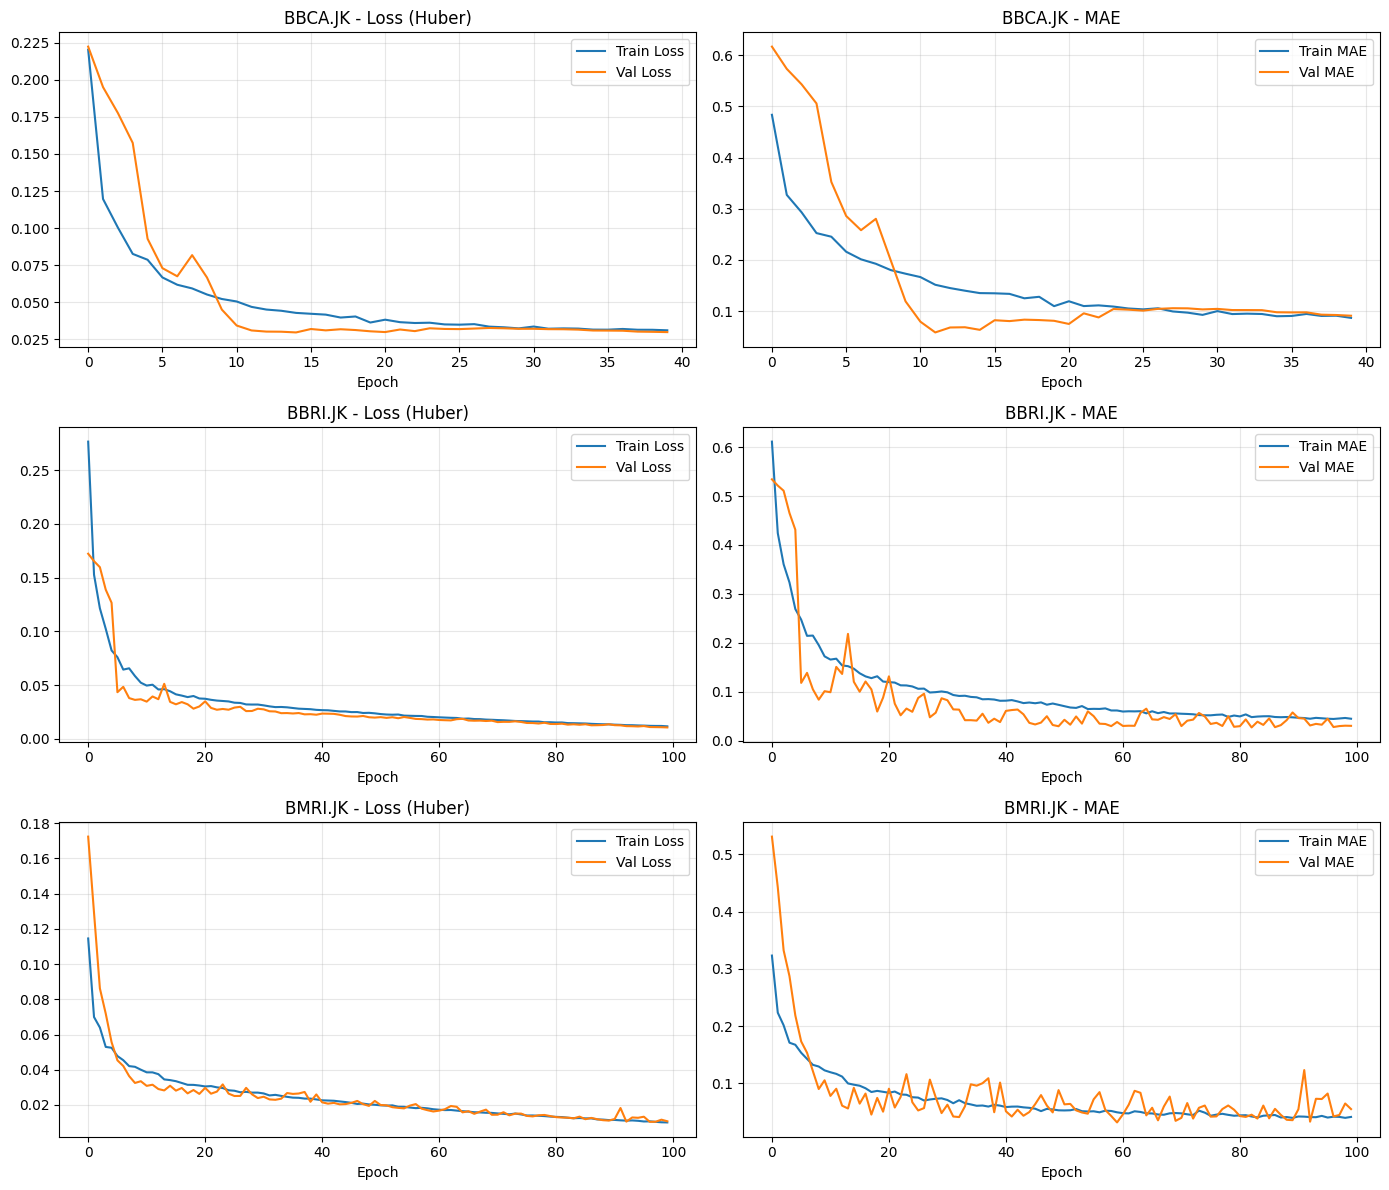

In [98]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    h = histories[ticker]

    axes[i, 0].plot(h['loss'],     label='Train Loss')
    axes[i, 0].plot(h['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{ticker} - Loss (Huber)')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h['mae'],     label='Train MAE')
    axes[i, 1].plot(h['val_mae'], label='Val MAE')
    axes[i, 1].set_title(f'{ticker} - MAE')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## Inverse-Transform Predictions

In [99]:
def inverse_close(scaler, scaled_values, n_features, target_idx):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

predictions = {}
n_feat = len(feature_cols)

for ticker in tickers:
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]

    y_pred_scaled = model.predict(s['X_test'],  verbose=0)
    y_tr_scaled   = model.predict(s['X_train'], verbose=0)

    predictions[ticker] = {
        'y_true':       inverse_close(scaler, s['y_test'],       n_feat, target_idx),
        'y_pred':       inverse_close(scaler, y_pred_scaled,     n_feat, target_idx),
        'y_train_true': inverse_close(scaler, s['y_train'],      n_feat, target_idx),
        'y_train_pred': inverse_close(scaler, y_tr_scaled,       n_feat, target_idx),
    }

print('Inverse transform done.')

Inverse transform done.


## Evaluation Metrics

In [100]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

rows = []
for ticker in tickers:
    p = predictions[ticker]
    rows.append({'Ticker': ticker, 'Split': 'Train', **evaluate(p['y_train_true'], p['y_train_pred'])})
    rows.append({'Ticker': ticker, 'Split': 'Test',  **evaluate(p['y_true'],       p['y_pred'])})

metrics_df = pd.DataFrame(rows).set_index(['Ticker', 'Split'])
metrics_df = metrics_df.round({'MAE': 2, 'RMSE': 2, 'MAPE': 4, 'R2': 4})

display(
    metrics_df.style
        .background_gradient(subset=['MAE','RMSE','MAPE'], cmap='RdYlGn_r')
        .background_gradient(subset=['R2'], cmap='RdYlGn')
        .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'})
)

## Prediction vs Actual

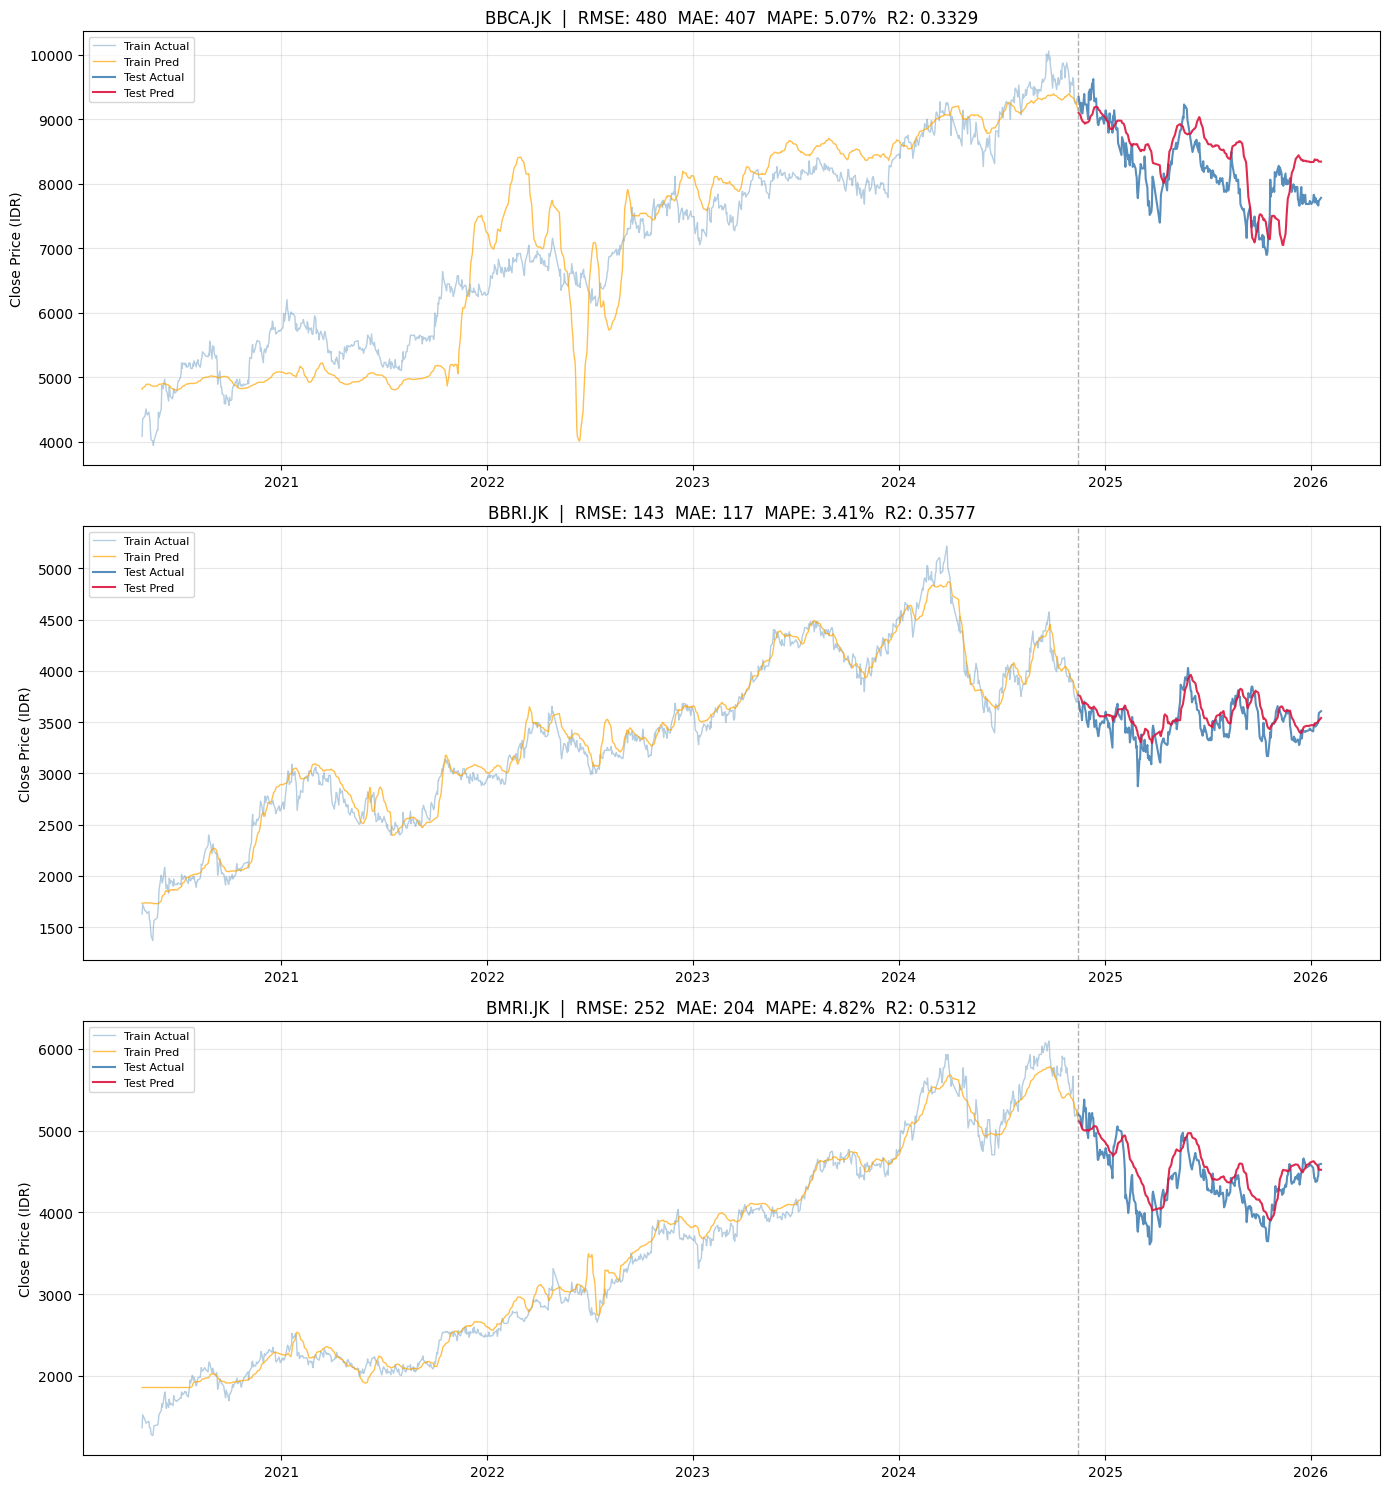

In [101]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 5 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])

    train_dates = dates[window_size : window_size + split]
    test_dates  = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(train_dates, p['y_train_true'], color='steelblue', alpha=0.4, lw=1,   label='Train Actual')
    ax.plot(train_dates, p['y_train_pred'], color='orange',    alpha=0.7, lw=1,   label='Train Pred')
    ax.plot(test_dates,  p['y_true'],       color='steelblue', alpha=0.9, lw=1.5, label='Test Actual')
    ax.plot(test_dates,  p['y_pred'],       color='crimson',   alpha=0.9, lw=1.5, label='Test Pred')
    ax.axvline(train_dates[-1], color='gray', linestyle='--', lw=1, alpha=0.6)

    m = evaluate(p['y_true'], p['y_pred'])
    ax.set_title(f"{ticker}  |  RMSE: {m['RMSE']:,.0f}  MAE: {m['MAE']:,.0f}  MAPE: {m['MAPE']:.2f}%  R2: {m['R2']:.4f}")
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'prediction_vs_actual.png'), dpi=120, bbox_inches='tight')
plt.show()

## Test Set Zoom

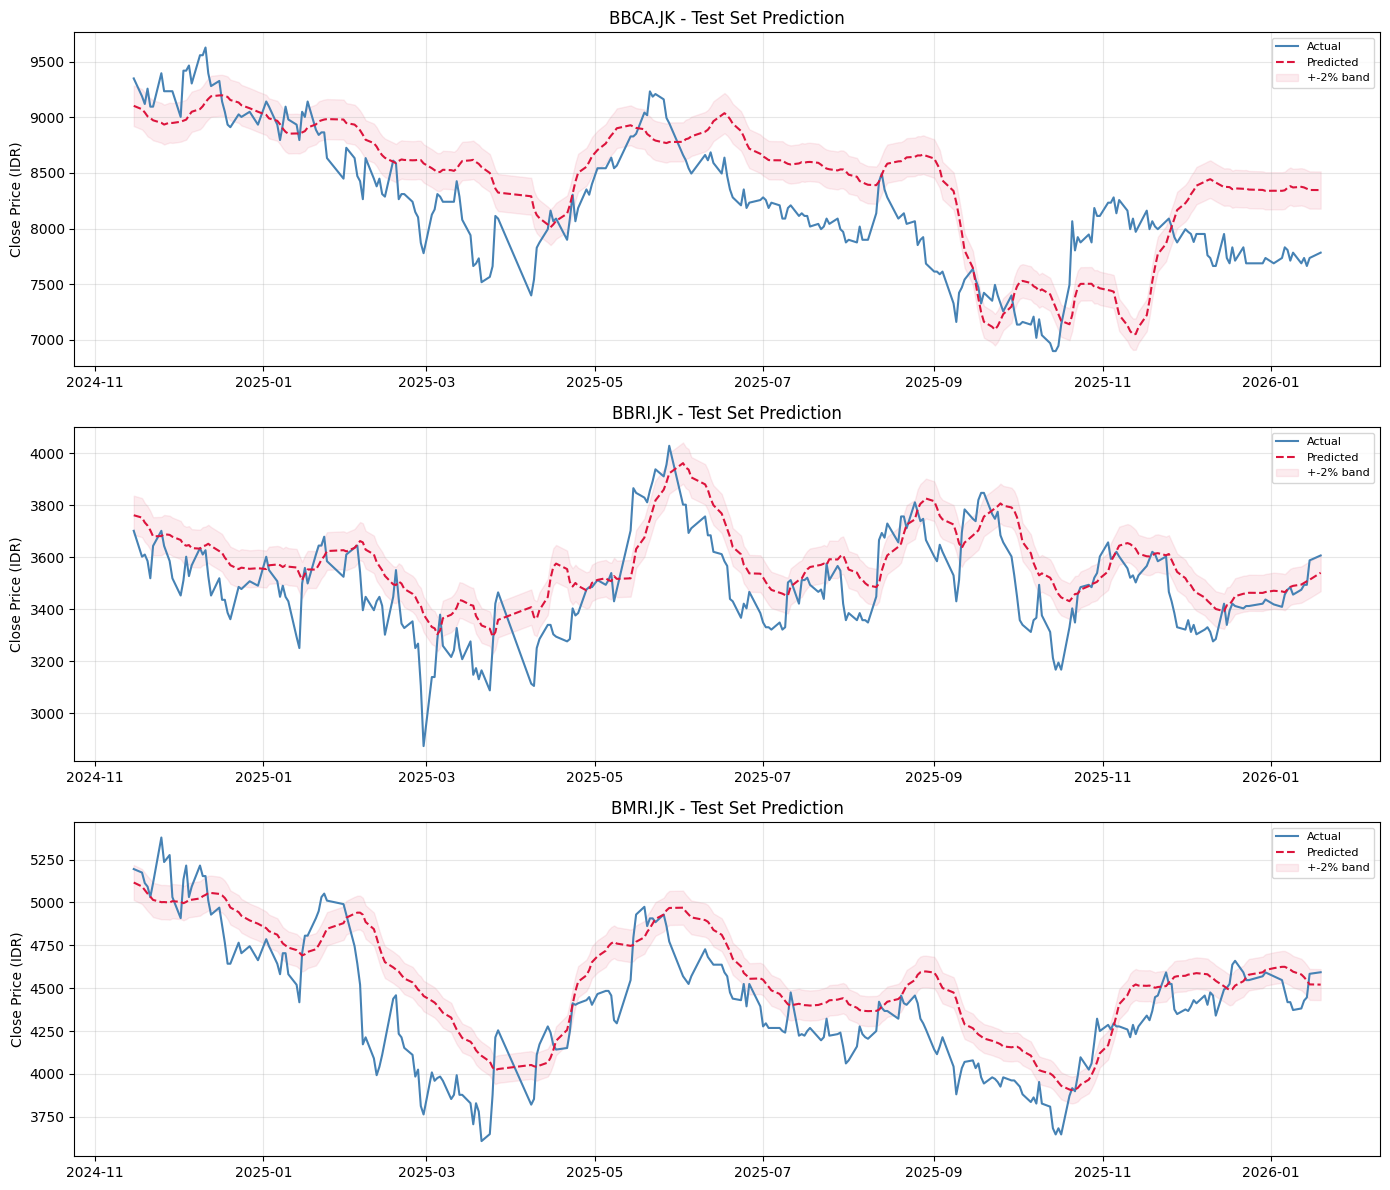

In [102]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])
    test_dates = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(test_dates, p['y_true'], color='steelblue', lw=1.5, label='Actual')
    ax.plot(test_dates, p['y_pred'], color='crimson',   lw=1.5, label='Predicted', linestyle='--')
    ax.fill_between(test_dates, p['y_pred'] * 0.98, p['y_pred'] * 1.02,
                    color='crimson', alpha=0.08, label='+-2% band')
    ax.set_title(f'{ticker} - Test Set Prediction')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'test_zoom.png'), dpi=120, bbox_inches='tight')
plt.show()

## Residual Analysis

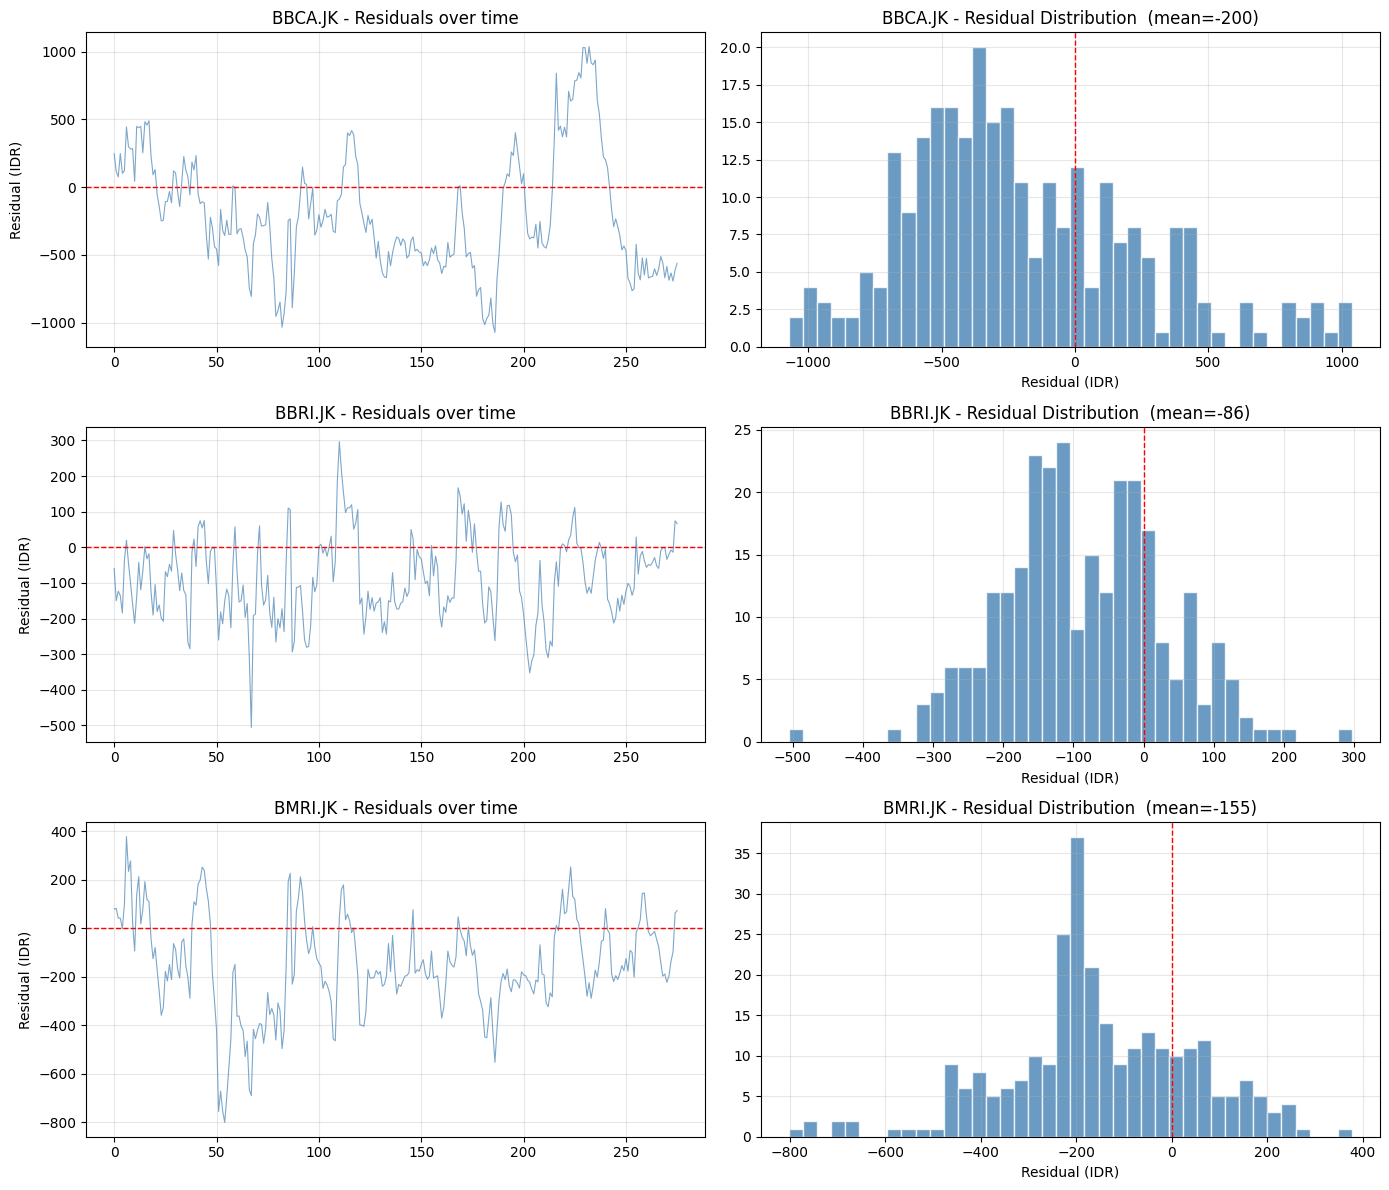

In [103]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p         = predictions[ticker]
    residuals = p['y_true'] - p['y_pred']

    axes[i, 0].plot(residuals, color='steelblue', lw=0.8, alpha=0.7)
    axes[i, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[i, 0].set_title(f'{ticker} - Residuals over time')
    axes[i, 0].set_ylabel('Residual (IDR)')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 1].axvline(0, color='red', linestyle='--', lw=1)
    axes[i, 1].set_title(f'{ticker} - Residual Distribution  (mean={residuals.mean():,.0f})')
    axes[i, 1].set_xlabel('Residual (IDR)')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'residuals.png'), dpi=120, bbox_inches='tight')
plt.show()

## Directional Accuracy

In [104]:
da_rows = []
for ticker in tickers:
    p = predictions[ticker]
    actual_dir = np.sign(np.diff(p['y_true']))
    pred_dir   = np.sign(np.diff(p['y_pred']))
    da = (actual_dir == pred_dir).mean() * 100
    da_rows.append({'Ticker': ticker, 'Directional Accuracy (%)': round(da, 2)})


In [105]:

da_df = pd.DataFrame(da_rows).set_index('Ticker')
display(da_df.style.background_gradient(cmap='RdYlGn', vmin=40, vmax=70))

,Directional Accuracy (%)
Ticker,
BBCA.JK,40.730000
BBRI.JK,48.360000
BMRI.JK,46.910000


## 30-Day Forecast

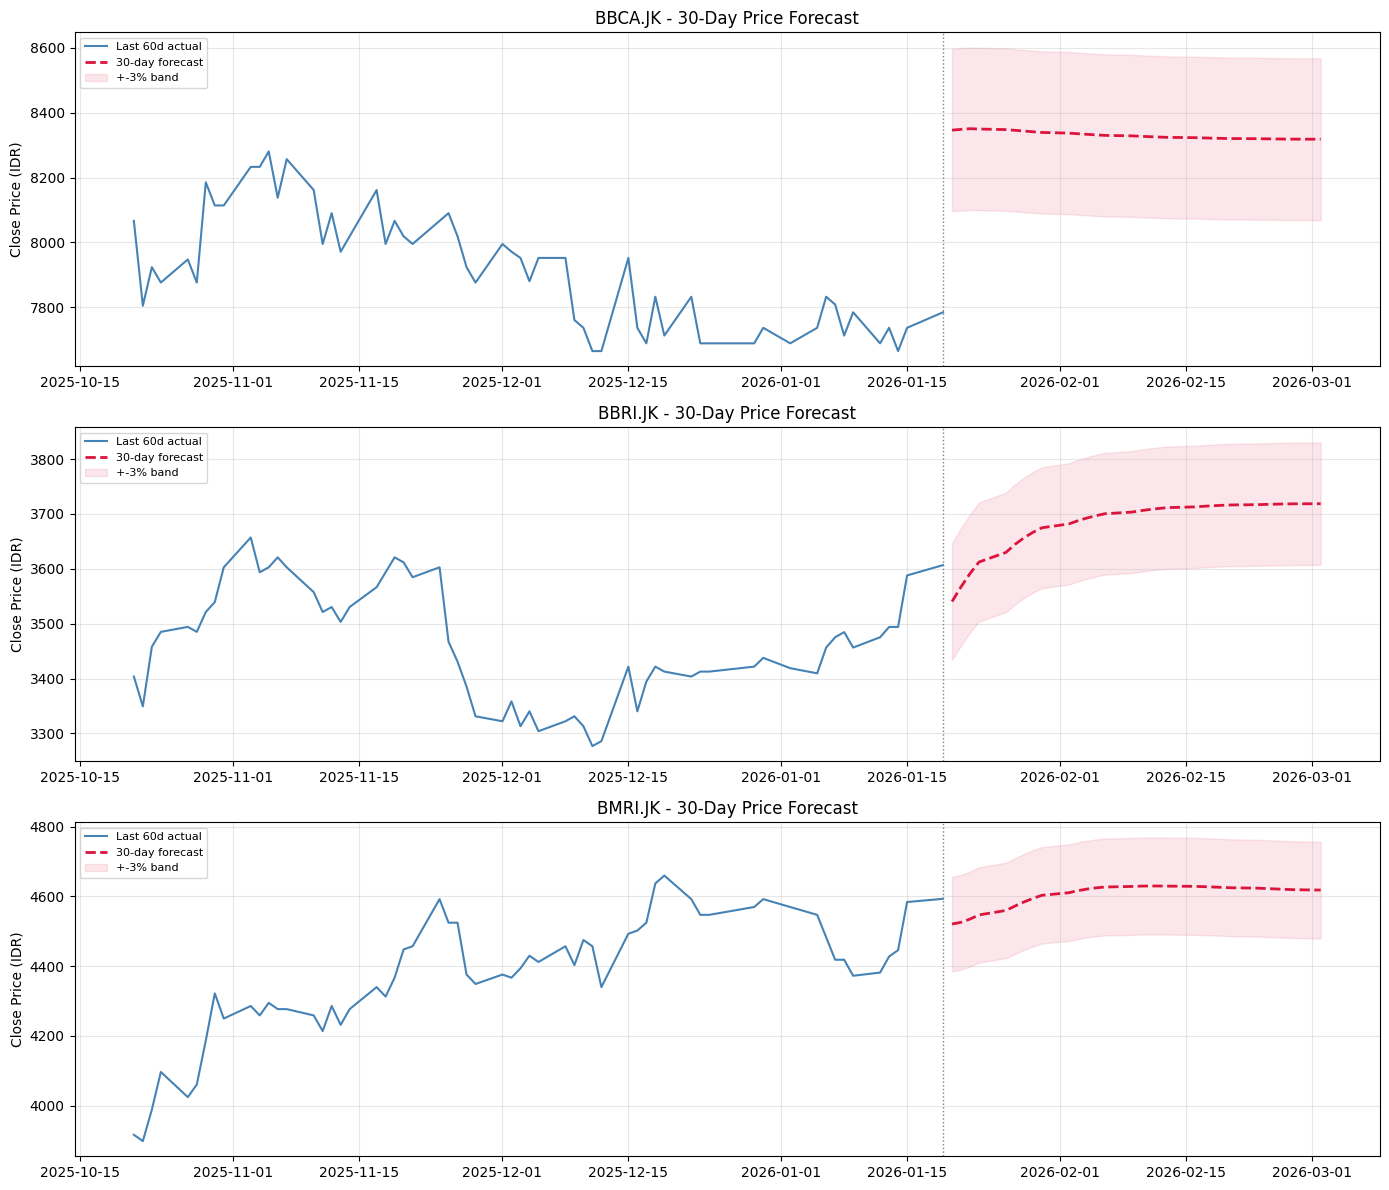

In [106]:
FORECAST_DAYS = 30

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]
    ax     = axes[i]

    last_window     = s['X_test'][-1].copy()
    forecast_scaled = []

    for _ in range(FORECAST_DAYS):
        pred = model.predict(last_window[np.newaxis], verbose=0)[0, 0]
        forecast_scaled.append(pred)
        new_step             = last_window[-1].copy()
        new_step[target_idx] = pred
        last_window          = np.vstack([last_window[1:], new_step])

    forecast     = inverse_close(scaler, np.array(forecast_scaled), len(feature_cols), target_idx)
    last_actuals = predictions[ticker]['y_true'][-60:]
    last_dates   = featured_data[ticker].index[-60:]
    future_dates = pd.bdate_range(start=last_dates[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

    ax.plot(last_dates,   last_actuals, color='steelblue', lw=1.5, label='Last 60d actual')
    ax.plot(future_dates, forecast,     color='crimson',   lw=2,   label=f'{FORECAST_DAYS}-day forecast', linestyle='--')
    ax.fill_between(future_dates, forecast * 0.97, forecast * 1.03,
                    color='crimson', alpha=0.1, label='+-3% band')
    ax.axvline(last_dates[-1], color='gray', linestyle=':', lw=1)
    ax.set_title(f'{ticker} - {FORECAST_DAYS}-Day Price Forecast')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'forecast_30d.png'), dpi=120, bbox_inches='tight')
plt.show()

## Summary

In [107]:
print('Final Test Metrics')
print('=' * 60)
test_metrics = metrics_df.xs('Test', level='Split')
display(
    test_metrics.style.format(
        {'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'}
    )
)
print('\nDirectional Accuracy')
display(da_df)

for ticker in tickers:
    runs = mlflow.search_runs(filter_string=f"tags.mlflow.runName = '{ticker}'",
                              order_by=["start_time DESC"])
    if not runs.empty:
        with mlflow.start_run(run_id=runs.iloc[0].run_id):
            m  = test_metrics.loc[ticker]
            da = da_df.loc[ticker, 'Directional Accuracy (%)']
            mlflow.log_metrics({
                'test_mae'  : m['MAE'],
                'test_rmse' : m['RMSE'],
                'test_mape' : m['MAPE'],
                'test_r2'   : m['R2'],
                'test_da'   : da,
            })

print(f'\nMLflow UI — jalankan di terminal:')
print(f'  mlflow ui --backend-store-uri sqlite:///{DB_PATH} --workers 1')
print(f'  lalu buka http://127.0.0.1:5000')
print(f'\nModels saved:')
for ticker in tickers:
    p = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')
    print(f'  {p}')

Final Test Metrics


,MAE,RMSE,MAPE,R2
Ticker,,,,
BBCA.JK,406.82,480.10,5.0700%,0.3329
BBRI.JK,116.52,143.43,3.4081%,0.3577
BMRI.JK,203.99,252.14,4.8195%,0.5312



Directional Accuracy


,Directional Accuracy (%)
Ticker,
BBCA.JK,40.73
BBRI.JK,48.36
BMRI.JK,46.91



MLflow UI — jalankan di terminal:
  mlflow ui --backend-store-uri sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db --workers 1
  lalu buka http://127.0.0.1:5000

Models saved:
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BBCA_JK_best.keras
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BBRI_JK_best.keras
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BMRI_JK_best.keras
